# Anomaly Detection with TuiML

This tutorial covers **anomaly detection** (also known as outlier detection) using TuiML's algorithms. Anomaly detection is the task of identifying rare items, events, or observations that deviate significantly from the majority of the data.

## What You'll Learn

- **IsolationForestDetector** — Tree-based ensemble that isolates anomalies
- **LocalOutlierFactorDetector** — Density-based detection using k-nearest neighbors
- **EllipticEnvelopeDetector** — Fits a Gaussian distribution to find outliers
- **OneClassSVMDetector** — Learns a boundary around normal data
- **ABODDetector** — Angle-based outlier detection for high-dimensional data

## Setup

First, let's import the necessary modules and create some sample data with anomalies.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Import anomaly detection algorithms
from tuiml.algorithms.anomaly import (
    IsolationForestDetector,
    LocalOutlierFactorDetector,
    EllipticEnvelopeDetector,
    OneClassSVMDetector,
    ABODDetector
)

# Set random seed for reproducibility
np.random.seed(42)

print("TuiML Anomaly Detection Algorithms:")
print("  - IsolationForestDetector")
print("  - LocalOutlierFactorDetector")
print("  - EllipticEnvelopeDetector")
print("  - OneClassSVMDetector")
print("  - ABODDetector")

TuiML Anomaly Detection Algorithms:
  - IsolationForestDetector
  - LocalOutlierFactorDetector
  - EllipticEnvelopeDetector
  - OneClassSVMDetector
  - ABODDetector


## Creating Sample Data with Anomalies

Let's create a dataset with clear normal clusters and some outliers.

In [3]:
# Generate normal data (two clusters)
n_normal = 200
cluster1 = np.random.randn(n_normal // 2, 2) + np.array([2, 2])
cluster2 = np.random.randn(n_normal // 2, 2) + np.array([-2, -2])
X_normal = np.vstack([cluster1, cluster2])

# Generate anomalies (scattered outliers)
n_anomalies = 20
X_anomalies = np.random.uniform(low=-6, high=6, size=(n_anomalies, 2))

# Combine data
X = np.vstack([X_normal, X_anomalies])
y_true = np.array([1] * n_normal + [-1] * n_anomalies)  # 1 = normal, -1 = anomaly

print(f"Dataset shape: {X.shape}")
print(f"Normal samples: {n_normal}")
print(f"Anomalies: {n_anomalies}")
print(f"Contamination rate: {n_anomalies / len(X):.1%}")

Dataset shape: (220, 2)
Normal samples: 200
Anomalies: 20
Contamination rate: 9.1%


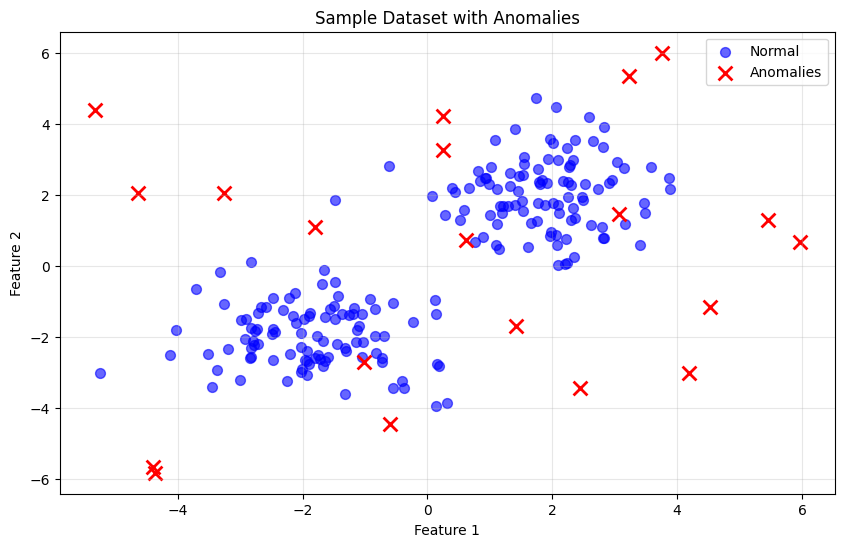

In [4]:
# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='blue', alpha=0.6, label='Normal', s=50)
plt.scatter(X_anomalies[:, 0], X_anomalies[:, 1], c='red', marker='x', s=100, 
            linewidths=2, label='Anomalies')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sample Dataset with Anomalies')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1. Isolation Forest (IsolationForestDetector)

**IsolationForestDetector** is a tree-based ensemble method that detects anomalies by **isolating observations**. The key insight is that anomalies are "few and different" — they can be isolated with fewer random splits than normal points.

### How It Works
1. Build random trees by selecting random features and split values
2. Anomalies are isolated quickly (short path length)
3. Normal points require more splits (longer path length)

**Best for:** High-dimensional data, unknown contamination rate

In [5]:
# Create and fit IsolationForestDetector
iso_forest = IsolationForestDetector(
    n_estimators=100,      # Number of trees
    contamination=0.1,     # Expected proportion of outliers
    random_state=42
)

iso_forest.fit(X)

# Predict: -1 for anomalies, 1 for normal
y_pred_iso = iso_forest.predict(X)

# Get anomaly scores (lower = more anomalous)
scores_iso = iso_forest.decision_function(X)

print("IsolationForestDetector Results:")
print(f"  Detected anomalies: {np.sum(y_pred_iso == -1)}")
print(f"  Detected normal: {np.sum(y_pred_iso == 1)}")
print(f"  Score range: [{scores_iso.min():.3f}, {scores_iso.max():.3f}]")

IsolationForestDetector Results:
  Detected anomalies: 197
  Detected normal: 23
  Score range: [-0.228, 0.148]


In [6]:
# Evaluate accuracy
from tuiml.evaluation import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_iso)
precision = precision_score(y_true, y_pred_iso, pos_label=-1)
recall = recall_score(y_true, y_pred_iso, pos_label=-1)
f1 = f1_score(y_true, y_pred_iso, pos_label=-1)

print(f"IsolationForestDetector Performance:")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Precision (anomaly): {precision:.2%}")
print(f"  Recall (anomaly): {recall:.2%}")
print(f"  F1-Score: {f1:.2%}")

IsolationForestDetector Performance:
  Accuracy: 19.55%
  Precision (anomaly): 10.15%
  Recall (anomaly): 100.00%
  F1-Score: 18.43%


## 2. Local Outlier Factor (LocalOutlierFactorDetector)

**LocalOutlierFactorDetector** is a density-based algorithm that measures the local density deviation of a point with respect to its neighbors. Points in low-density regions compared to their neighbors are considered outliers.

### How It Works
1. For each point, find its k-nearest neighbors
2. Compute the local reachability density (LRD)
3. LOF score = ratio of average LRD of neighbors to point's LRD
4. LOF ≈ 1 means normal, LOF >> 1 means anomaly

**Best for:** Datasets with varying density clusters

In [7]:
# Create and fit LocalOutlierFactorDetector
lof = LocalOutlierFactorDetector(
    n_neighbors=20,        # Number of neighbors to use
    contamination=0.1,     # Expected proportion of outliers
)

# LOF computes predictions during fit
y_pred_lof = lof.fit_predict(X)

# Get LOF scores (more negative = more anomalous)
scores_lof = lof.lof_scores_

print("LocalOutlierFactorDetector Results:")
print(f"  Detected anomalies: {np.sum(y_pred_lof == -1)}")
print(f"  Detected normal: {np.sum(y_pred_lof == 1)}")
print(f"  LOF score range: [{scores_lof.min():.3f}, {scores_lof.max():.3f}]")

LocalOutlierFactorDetector Results:
  Detected anomalies: 22
  Detected normal: 198
  LOF score range: [0.935, 4.380]


In [8]:
# Evaluate LOF
accuracy_lof = accuracy_score(y_true, y_pred_lof)
precision_lof = precision_score(y_true, y_pred_lof, pos_label=-1)
recall_lof = recall_score(y_true, y_pred_lof, pos_label=-1)
f1_lof = f1_score(y_true, y_pred_lof, pos_label=-1)

print(f"LocalOutlierFactorDetector Performance:")
print(f"  Accuracy: {accuracy_lof:.2%}")
print(f"  Precision (anomaly): {precision_lof:.2%}")
print(f"  Recall (anomaly): {recall_lof:.2%}")
print(f"  F1-Score: {f1_lof:.2%}")

LocalOutlierFactorDetector Performance:
  Accuracy: 95.45%
  Precision (anomaly): 72.73%
  Recall (anomaly): 80.00%
  F1-Score: 76.19%


## 3. Elliptic Envelope (EllipticEnvelopeDetector)

**EllipticEnvelopeDetector** fits a robust covariance estimate to the data, assuming it follows a Gaussian distribution. Points outside the ellipsoidal boundary are considered anomalies.

### How It Works
1. Fit a robust estimate of covariance (Minimum Covariance Determinant)
2. Compute Mahalanobis distance for each point
3. Points with high Mahalanobis distance are outliers

**Best for:** Data that is roughly Gaussian with outliers

In [9]:
# Create and fit EllipticEnvelopeDetector
elliptic = EllipticEnvelopeDetector(
    contamination=0.1,     # Expected proportion of outliers
    random_state=42
)

elliptic.fit(X)
y_pred_elliptic = elliptic.predict(X)
scores_elliptic = elliptic.decision_function(X)

print("EllipticEnvelopeDetector Results:")
print(f"  Detected anomalies: {np.sum(y_pred_elliptic == -1)}")
print(f"  Detected normal: {np.sum(y_pred_elliptic == 1)}")

EllipticEnvelopeDetector Results:
  Detected anomalies: 22
  Detected normal: 198


In [10]:
# Evaluate EllipticEnvelopeDetector
accuracy_ell = accuracy_score(y_true, y_pred_elliptic)
f1_ell = f1_score(y_true, y_pred_elliptic, pos_label=-1)

print(f"EllipticEnvelopeDetector Performance:")
print(f"  Accuracy: {accuracy_ell:.2%}")
print(f"  F1-Score: {f1_ell:.2%}")

EllipticEnvelopeDetector Performance:
  Accuracy: 93.64%
  F1-Score: 66.67%


## 4. One-Class SVM (OneClassSVMDetector)

**OneClassSVMDetector** learns a decision boundary that encompasses the normal data. Points outside this boundary are classified as anomalies.

### How It Works
1. Map data to a high-dimensional feature space (using kernel)
2. Find a hyperplane that separates data from the origin
3. Maximize the margin between the hyperplane and the origin

**Best for:** Novel class detection, when you only have normal samples for training

In [11]:
# Create and fit OneClassSVMDetector
oc_svm = OneClassSVMDetector(
    kernel='rbf',          # Radial basis function kernel
    gamma='scale',         # Kernel coefficient
    nu=0.1                 # Upper bound on fraction of outliers
)

oc_svm.fit(X)
y_pred_svm = oc_svm.predict(X)
scores_svm = oc_svm.decision_function(X)

print("OneClassSVMDetector Results:")
print(f"  Detected anomalies: {np.sum(y_pred_svm == -1)}")
print(f"  Detected normal: {np.sum(y_pred_svm == 1)}")

OneClassSVMDetector Results:
  Detected anomalies: 110
  Detected normal: 110


In [12]:
# Evaluate OneClassSVMDetector
accuracy_svm = accuracy_score(y_true, y_pred_svm)
f1_svm = f1_score(y_true, y_pred_svm, pos_label=-1)

print(f"OneClassSVMDetector Performance:")
print(f"  Accuracy: {accuracy_svm:.2%}")
print(f"  F1-Score: {f1_svm:.2%}")

OneClassSVMDetector Performance:
  Accuracy: 58.18%
  F1-Score: 29.23%


## 5. ABOD (ABODDetector)

**ABODDetector** uses the variance of angles between a point and all pairs of other points. Outliers have a smaller variance in angles because they are "surrounded" from fewer directions.

### How It Works
1. For each point, compute angles formed with all pairs of other points
2. Calculate the variance of these angles
3. Low variance = anomaly (point is far from others)

**Best for:** High-dimensional data where distance-based methods struggle

In [13]:
# Create and fit ABODDetector
abod = ABODDetector(
    n_neighbors=10,        # Use approximate ABOD with k neighbors
    contamination=0.1
)

abod.fit(X)
y_pred_abod = abod.predict(X)

print("ABODDetector Results:")
print(f"  Detected anomalies: {np.sum(y_pred_abod == -1)}")
print(f"  Detected normal: {np.sum(y_pred_abod == 1)}")

ABODDetector Results:
  Detected anomalies: 22
  Detected normal: 198


In [14]:
# Evaluate ABODDetector
accuracy_abod = accuracy_score(y_true, y_pred_abod)
f1_abod = f1_score(y_true, y_pred_abod, pos_label=-1)

print(f"ABODDetector Performance:")
print(f"  Accuracy: {accuracy_abod:.2%}")
print(f"  F1-Score: {f1_abod:.2%}")

ABODDetector Performance:
  Accuracy: 88.18%
  F1-Score: 38.10%


## Comparing All Algorithms

Let's compare the performance of all anomaly detection algorithms.

In [15]:
# Summary comparison
results = {
    'IsolationForestDetector': (accuracy, f1),
    'LocalOutlierFactorDetector': (accuracy_lof, f1_lof),
    'EllipticEnvelopeDetector': (accuracy_ell, f1_ell),
    'OneClassSVMDetector': (accuracy_svm, f1_svm),
    'ABODDetector': (accuracy_abod, f1_abod),
}

print("\n" + "="*60)
print("ALGORITHM COMPARISON")
print("="*60)
print(f"{'Algorithm':<30} {'Accuracy':>12} {'F1-Score':>12}")
print("-"*60)
for name, (acc, f1) in results.items():
    print(f"{name:<30} {acc:>11.1%} {f1:>11.1%}")
print("="*60)


ALGORITHM COMPARISON
Algorithm                          Accuracy     F1-Score
------------------------------------------------------------
IsolationForestDetector              19.5%       18.4%
LocalOutlierFactorDetector           95.5%       76.2%
EllipticEnvelopeDetector             93.6%       66.7%
OneClassSVMDetector                  58.2%       29.2%
ABODDetector                         88.2%       38.1%


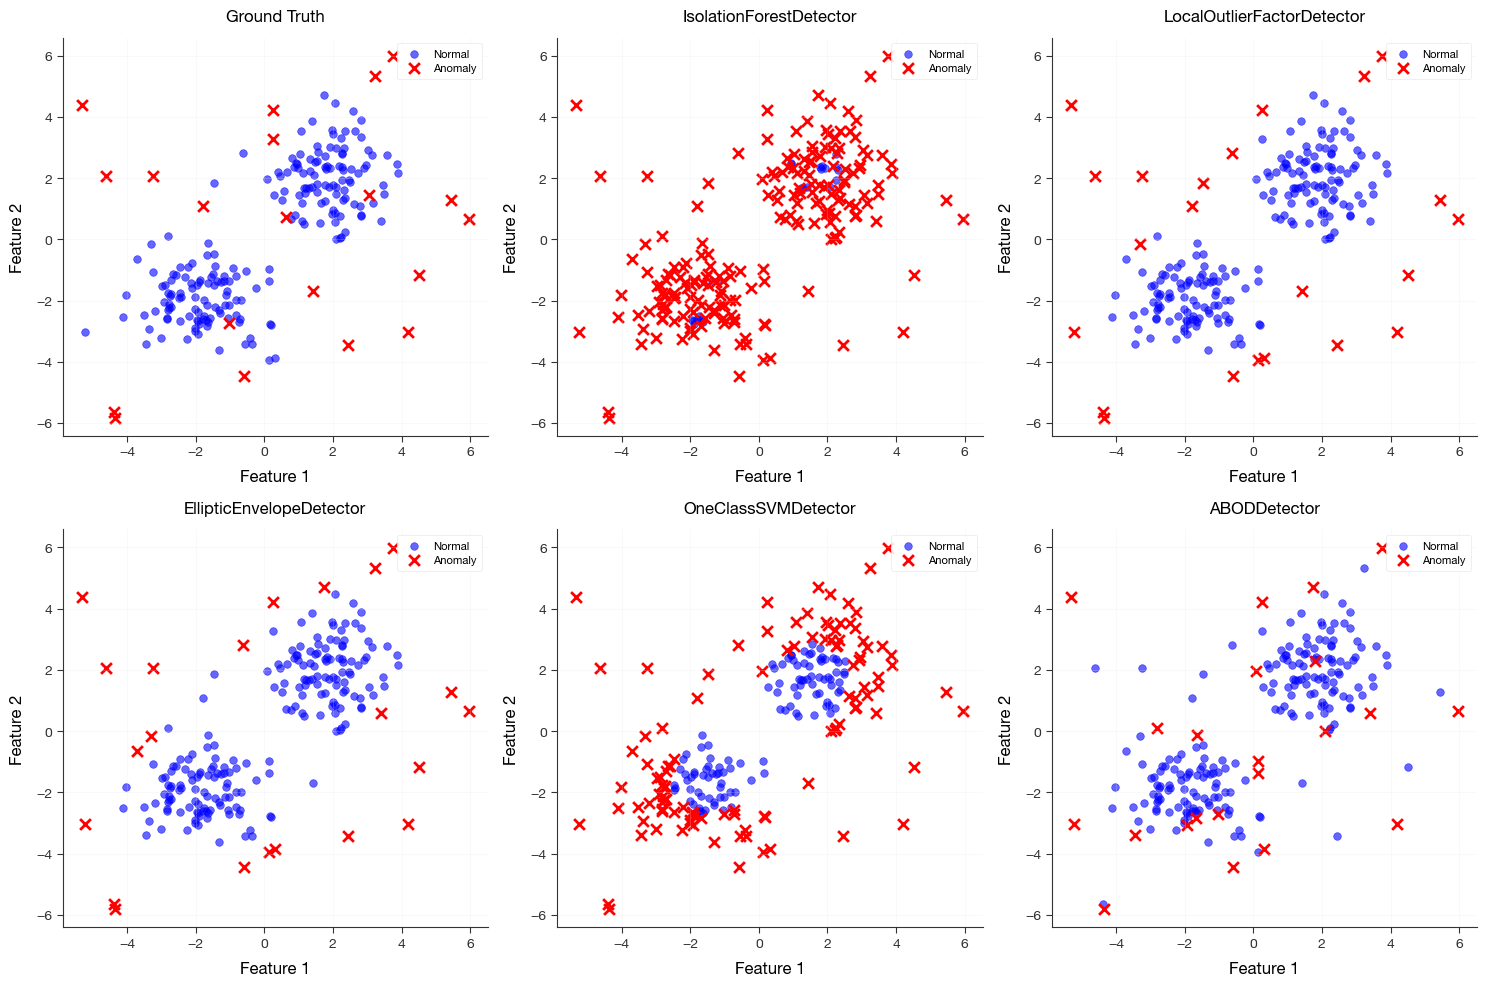

In [16]:
# Visualize predictions from all algorithms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

predictions = [
    (y_true, 'Ground Truth'),
    (y_pred_iso, 'IsolationForestDetector'),
    (y_pred_lof, 'LocalOutlierFactorDetector'),
    (y_pred_elliptic, 'EllipticEnvelopeDetector'),
    (y_pred_svm, 'OneClassSVMDetector'),
    (y_pred_abod, 'ABODDetector'),
]

for ax, (y_pred, title) in zip(axes.flat, predictions):
    normal_mask = y_pred == 1
    anomaly_mask = y_pred == -1
    
    ax.scatter(X[normal_mask, 0], X[normal_mask, 1], c='blue', alpha=0.6, label='Normal', s=30)
    ax.scatter(X[anomaly_mask, 0], X[anomaly_mask, 1], c='red', marker='x', s=60, 
               linewidths=2, label='Anomaly')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Real-World Example: Credit Card Fraud Detection

Let's apply anomaly detection to a more realistic scenario using the built-in datasets.

In [17]:
from tuiml.datasets import load_ionosphere
from tuiml.preprocessing import StandardScaler

# Load ionosphere dataset (has anomalous radar returns)
X_iono, y_iono = load_ionosphere()

# Convert labels: 'b' (bad) = anomaly (-1), 'g' (good) = normal (1)
y_binary = np.where(y_iono == 'b', -1, 1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iono)

print(f"Ionosphere Dataset:")
print(f"  Samples: {X_iono.shape[0]}")
print(f"  Features: {X_iono.shape[1]}")
print(f"  Anomalies (bad): {np.sum(y_binary == -1)}")
print(f"  Normal (good): {np.sum(y_binary == 1)}")

Ionosphere Dataset:
  Samples: 351
  Features: 34
  Anomalies (bad): 0
  Normal (good): 351


In [18]:
# Calculate contamination rate
contamination_rate = np.sum(y_binary == -1) / len(y_binary)
print(f"Contamination rate: {contamination_rate:.1%}")

# Apply IsolationForestDetector
iso_iono = IsolationForestDetector(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42
)
iso_iono.fit(X_scaled)
y_pred_iono = iso_iono.predict(X_scaled)

# Evaluate
acc_iono = accuracy_score(y_binary, y_pred_iono)
prec_iono = precision_score(y_binary, y_pred_iono, pos_label=-1)
rec_iono = recall_score(y_binary, y_pred_iono, pos_label=-1)
f1_iono = f1_score(y_binary, y_pred_iono, pos_label=-1)

print(f"\nIsolationForestDetector on Ionosphere:")
print(f"  Accuracy: {acc_iono:.2%}")
print(f"  Precision: {prec_iono:.2%}")
print(f"  Recall: {rec_iono:.2%}")
print(f"  F1-Score: {f1_iono:.2%}")

Contamination rate: 0.0%

IsolationForestDetector on Ionosphere:
  Accuracy: 0.28%
  Precision: 0.00%
  Recall: 0.00%
  F1-Score: 0.00%


## Choosing the Right Algorithm

| Algorithm | Best For | Pros | Cons |
|-----------|----------|------|------|
| **IsolationForestDetector** | High-dimensional data, large datasets | Fast, scalable, no assumptions | May struggle with local anomalies |
| **LocalOutlierFactorDetector** | Datasets with varying density | Captures local anomalies | Computationally expensive |
| **EllipticEnvelopeDetector** | Gaussian-distributed data | Simple, interpretable | Assumes Gaussian distribution |
| **OneClassSVMDetector** | Training only on normal data | Powerful with right kernel | Sensitive to parameters |
| **ABODDetector** | High-dimensional data | Robust to curse of dimensionality | Can be slow |

### Tips

1. **Start with IsolationForestDetector** — It's fast and works well in most cases
2. **Use LocalOutlierFactorDetector for local anomalies** — When anomalies exist in dense regions
3. **EllipticEnvelopeDetector for Gaussian data** — Simple and effective
4. **OneClassSVMDetector for novelty detection** — When you only have normal samples
5. **ABODDetector for very high dimensions** — When distance-based methods fail

## Summary

In this tutorial, you learned:

- **5 anomaly detection algorithms** available in TuiML
- How to **fit models and make predictions** (returns -1 for anomalies, 1 for normal)
- How to **evaluate performance** using accuracy, precision, recall, and F1-score
- **When to use each algorithm** based on data characteristics